In [17]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['text.usetex']=True
plt.style.use('classic')

from scipy.interpolate import UnivariateSpline

import framework as fw
from framework import FrameWork

from framework import AveragedPerdiction

In [18]:
f_c    = 1.166 #Fermi constant :  1.166 \times 10^{-11}/Mev^2
m_e    = 0.511 #Electron mass : 0.511 Mev
hbarc  = 1.97 #h_{bar}c : 1.97 10^{-11} Mev.cm
m_p    = 1.67 #proton mass :  1.67 \times 10^{-27} kg
g      = hbarc * f_c

In [19]:
frame = FrameWork(su_nbin=13,m12_nuisance=False)
#chi = frame[[33.4,3.75e-11]]
#chi2 = frame[[33.4,0.]]

{'T12': 33.4, 'T13': 8.57, 'mum1': np.float64(0.0), 'mum2': 0.0, 'mum3': 0.0, 'M12': 7.54e-05}


/var/folders/1l/bbx9plw91szdlygvs9b6y59h0000gn/T/ipykernel_5241/1480986954.py:37: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  PeeB8_av= (1/(frame.h*frame.year)) * np.trapz(frame.l[:,np.newaxis]**2*PeeB8,frame.theta,axis=0)


{'T12': 33.4, 'T13': 8.57, 'mum1': np.float64(5e-12), 'mum2': 0.0, 'mum3': 0.0, 'M12': 7.54e-05}
{'T12': 33.4, 'T13': 8.57, 'mum1': np.float64(7.5e-12), 'mum2': 0.0, 'mum3': 0.0, 'M12': 7.54e-05}
{'T12': 33.4, 'T13': 8.57, 'mum1': np.float64(1.5e-11), 'mum2': 0.0, 'mum3': 0.0, 'M12': 7.54e-05}
{'T12': 33.4, 'T13': 8.57, 'mum1': 0.0, 'mum2': np.float64(0.0), 'mum3': 0.0, 'M12': 7.54e-05}


/var/folders/1l/bbx9plw91szdlygvs9b6y59h0000gn/T/ipykernel_5241/1480986954.py:59: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  PeeB8_av= (1/(frame.h*frame.year)) * np.trapz(frame.l[:,np.newaxis]**2*PeeB8,frame.theta,axis=0)


{'T12': 33.4, 'T13': 8.57, 'mum1': 0.0, 'mum2': np.float64(5e-12), 'mum3': 0.0, 'M12': 7.54e-05}
{'T12': 33.4, 'T13': 8.57, 'mum1': 0.0, 'mum2': np.float64(7.5e-12), 'mum3': 0.0, 'M12': 7.54e-05}
{'T12': 33.4, 'T13': 8.57, 'mum1': 0.0, 'mum2': np.float64(1.5e-11), 'mum3': 0.0, 'M12': 7.54e-05}


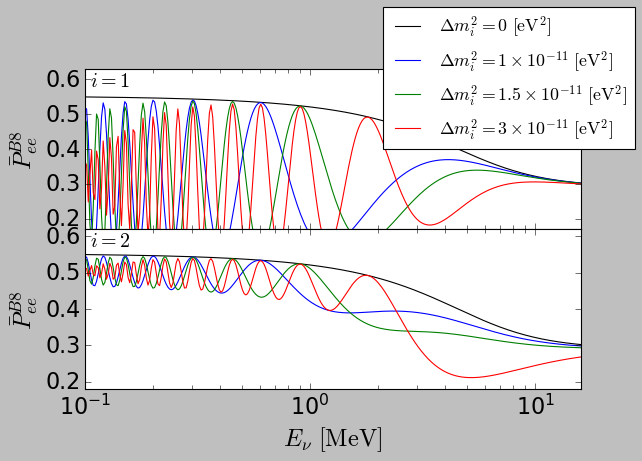

In [20]:
Enu   = np.logspace(-1,np.log10(16),300)
T12   = 33.4
M12   = 7.42e-5
mum2  = np.array([0.,0.5e-11,0.75e-11,1.5e-11])

color = ['k','b','g','r']
label = [r'$\Delta m_i^2 = 0 \ \rm [eV^2] $',
         r'$\Delta m_i^2 =  1 \times 10^{-11} \ \rm [eV^2] $',
         r'$\Delta m_i^2 =  1.5 \times 10^{-11} \ \rm [eV^2] $',
         r'$\Delta m_i^2 =  3 \times 10^{-11} \ \rm [eV^2] $']

plt.rcParams.update({'font.size': 20})
fig  = plt.figure(figsize=(8,5))

fig.subplots_adjust(hspace=0.0)
fig.subplots_adjust(wspace=0.0)



ax1 = fig.add_subplot(211)
ax1.set_ylim(0.17,0.63)
ax1.set_xlim(0.1,16)
ax1.set_xscale('log')

ax1.tick_params(axis='both', which='minor', length=4)
ax1.tick_params(axis='both', which='major', length=5)

#ax1.set_xlabel(r'$E_\nu \ \rm [MeV]$',fontsize=18)
ax1.set_ylabel(r'$ \bar{P}^{B8}_{ee} $',fontsize=22)
ax1.xaxis.set_major_formatter(plt.NullFormatter())
frame.param['mum1'] = 0.
frame.param['mum2'] = 0.
for i,m in enumerate(mum2):
    frame.param['mum1'] = m
    print(frame.param)
    PeeB8,_ = fw.SurvivalProbablity(frame.phi['B8'],Enu,frame.n_e,f_c,hbarc,frame.param,frame.l)
    PeeB8_av= (1/(frame.h*frame.year)) * np.trapz(frame.l[:,np.newaxis]**2*PeeB8,frame.theta,axis=0)
    ax1.plot(Enu,PeeB8_av,color=color[i],label=label[i])
ax1.set_title(r'$i = 1$',y=1.0, pad=-15, x=.05, fontsize=18)
    

ax0 = fig.add_subplot(212)
ax0.set_ylim(0.18,0.62)
ax0.set_xlim(0.1,16)
ax0.set_xscale('log')

ax0.tick_params(axis='both', which='minor', length=4)
ax0.tick_params(axis='both', which='major', length=5)

ax0.set_xlabel(r'$E_\nu \ \rm [MeV]$',fontsize=22)
ax0.set_ylabel(r'$ \bar{P}^{B8}_{ee}$',fontsize=22)

frame.param['mum1'] = 0.
frame.param['mum2'] = 0.
for i,m in enumerate(mum2):
    frame.param['mum2'] = m
    print(frame.param)
    PeeB8,_ = fw.SurvivalProbablity(frame.phi['B8'],Enu,frame.n_e,f_c,hbarc,frame.param,frame.l)
    PeeB8_av= (1/(frame.h*frame.year)) * np.trapz(frame.l[:,np.newaxis]**2*PeeB8,frame.theta,axis=0)
    ax0.plot(Enu,PeeB8_av,color=color[i],label=label[i])
ax0.set_title(r'$i = 2$',y=1.0, pad=-15, x=.05,fontsize=18)
    

    
plt.legend(loc=(0.6,1.5),fontsize=16)

#plt.savefig('Pee.pdf',bbox_inches='tight')

/var/folders/1l/bbx9plw91szdlygvs9b6y59h0000gn/T/ipykernel_5241/3971807766.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  P[i]      = PeeB8[frame.l==np.max(frame.l)] - PeeB8[frame.l==np.min(frame.l)]
/var/folders/1l/bbx9plw91szdlygvs9b6y59h0000gn/T/ipykernel_5241/3971807766.py:49: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  P[i]    = PeeB8[frame.l==np.max(frame.l)] - PeeB8[frame.l==np.min(frame.l)]


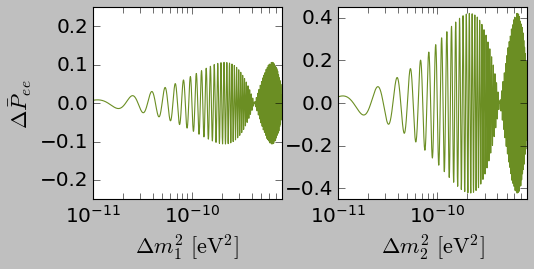

In [21]:
frame.param['mum1'] = 0.
frame.param['mum2'] = 0.

Enu   = np.array([0.862])
T12   = 33.4
M12   = 7.54e-5

mum2 = np.logspace(np.log10(5e-12),np.log10(4e-10),2000)
plt.rcParams.update({'font.size': 18})
fig  = plt.figure(figsize=(7,3))


fig.subplots_adjust(hspace=0.)
fig.subplots_adjust(wspace=0.3)

ax0 = fig.add_subplot(122)
ax0.set_xlim(1e-11,8e-10)
ax0.set_ylim(-0.45,0.45)
ax0.set_xscale('log')
ax0.tick_params(axis='both', which='minor', length=5)
ax0.tick_params(axis='both', which='major', length=6)
ax0.set_xlabel(r'$\Delta m^2_2 \ \rm [eV^2]$',fontsize=20)
#ax0.set_ylabel(r'$  \Delta \bar{P}_{ee} $',fontsize=18)
#ax0.yaxis.set_major_formatter(plt.NullFormatter())
P      = np.zeros(mum2.shape)
for i,m in enumerate(mum2):
    frame.param['mum1'] = m
    PeeB8,_ = fw.SurvivalProbablity(frame.phi['Be7'],Enu,frame.n_e,f_c,hbarc,frame.param,frame.l)
    P[i]      = PeeB8[frame.l==np.max(frame.l)] - PeeB8[frame.l==np.min(frame.l)]

ax0.plot(2*mum2,P,color='olivedrab')


ax1 = fig.add_subplot(121)
ax1.set_xlim(1e-11,8e-10)
ax1.set_ylim(-0.25,0.25)
ax1.set_xscale('log')
ax1.set_xlabel(r'$\Delta m^2_1 \ \rm [eV^2]$',fontsize=20)
ax1.set_ylabel(r'$  \Delta \bar{P}_{ee} $',fontsize=20)
#ax1.yaxis.set_major_formatter(plt.NullFormatter())
ax1.tick_params(axis='both', which='minor', length=5)
ax1.tick_params(axis='both', which='major', length=6)
P      = np.zeros(mum2.shape)
frame.param['mum1'] = 0.
frame.param['mum2'] = 0.
for i,m in enumerate(mum2):
    frame.param['mum2'] = m
    PeeB8,_ = fw.SurvivalProbablity(frame.phi['Be7'],Enu,frame.n_e,f_c,hbarc,frame.param,frame.l)
    P[i]    = PeeB8[frame.l==np.max(frame.l)] - PeeB8[frame.l==np.min(frame.l)]

#print(P)    
ax1.plot(2*mum2,P,color='olivedrab')

#plt.savefig('Delta_Pee.pdf',bbox_inches='tight')

[134.   48.3 121.5] [14.   1.3 21. ]
[137.71769627  48.31094759 138.0672499 ]
[120.65980427  40.12045087 102.36796014]
[119.80059826  47.65657868 105.89063306]
[121.31315507  46.80531352 118.08296956]


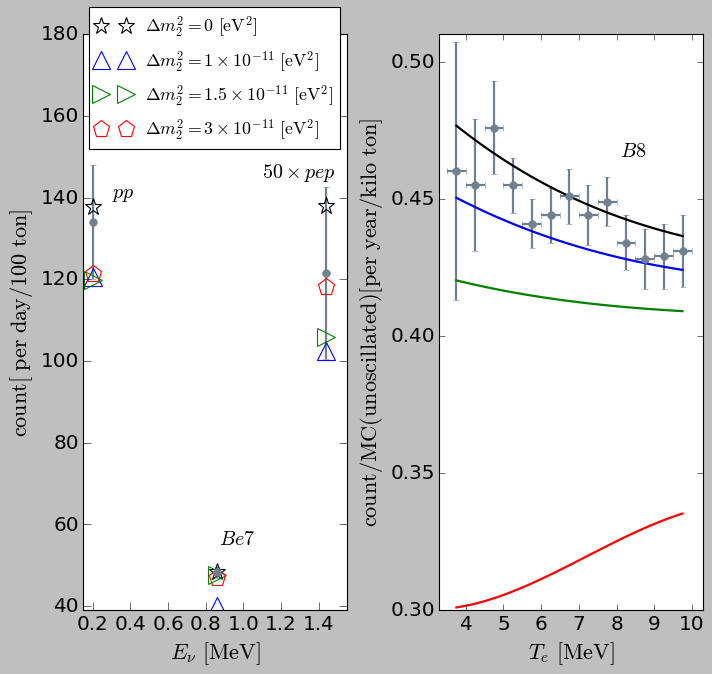

In [22]:
from scipy.interpolate import UnivariateSpline

plt.rcParams['text.usetex']=True
plt.style.use('classic')

#frame= framework(13,'mum2',False)
resu = frame.res

D_Su = frame.data_su
D_Bo = np.array([frame.data_bo['pp']['R'],frame.data_bo['Be7']['R'],frame.data_bo['pep']['R']])
E_Bo = np.array([frame.data_bo['pp']['e'],frame.data_bo['Be7']['e'],frame.data_bo['pep']['e']])
X_Bo = np.array([0.2,0.862,1.44])

T12   = 33.4
M12   = 7.42e-5
mum2  = np.array([0.,0.5e-11,0.75e-11,1.5e-11])

color = ['k','b','g','r']
label = [r'$\Delta m_2^2 = 0 \ \rm [eV^2] $',
         r'$\Delta m_2^2 =  1 \times 10^{-11} \ \rm [eV^2] $',
         r'$\Delta m_2^2 =  1.5 \times 10^{-11} \ \rm [eV^2] $',
         r'$\Delta m_2^2 =  3 \times 10^{-11} \ \rm [eV^2] $']


plt.rcParams.update({'font.size': 18})
fig = plt.figure(figsize=(10,9))


fig.subplots_adjust(hspace=0.0)
fig.subplots_adjust(wspace=0.35)

ax0 = fig.add_subplot(122)


#ax0.set_xscale('log')
#ax0.set_yscale('log')
ax0.set_xlim(3.3,10.3)
ax0.set_ylim(0.30,0.51)
#ax0.yaxis.set_major_formatter(plt.NullFormatter())
ax0.set_xlabel(r'$T_e \ \rm [MeV]$',fontsize=20)
ax0.set_ylabel(r'$ \rm count/MC(unoscillated) [per \ year/kilo \ ton ]$',fontsize=20)
ax0.tick_params(axis='both', which='minor', length=4)
ax0.tick_params(axis='both', which='major', length=5)

ax0.errorbar((D_Su[:,0]+D_Su[:,1])/2,D_Su[:,2],D_Su[:,3],(D_Su[:,1]-D_Su[:,0])/2,fmt='.',color='slategrey',
            ms=14,lw=2)

#slategrey
ax1   = fig.add_subplot(121)
#ax1.set_yscale('log')
ax1.set_xlim(0.15,1.55)
ax1.set_ylim(39,180)
ax1.set_ylabel(r'$ \rm count [\ per \ day/100 \ ton ]$',fontsize=20)
ax1.set_xlabel(r'$E_\nu \ \rm [MeV]$',fontsize=20)
ax1.tick_params(axis='both', which='minor', length=6)
ax1.tick_params(axis='both', which='major', length=7)
D_Bo[2] = 50*D_Bo[2]
E_Bo[2] = 50*E_Bo[2]
ax1.errorbar(X_Bo,D_Bo,E_Bo,fmt='.',color='slategrey',ms=14,lw=2)
print(D_Bo,E_Bo)
s = ['*','^','>','p']
for i,m in enumerate(mum2):
    dr_dldt = frame[[T12,m]]
    pred_bo, pred_su = AveragedPerdiction(dr_dldt,frame)
    TiB = pred_bo[0]
    TiS = pred_su[0]
    spl = UnivariateSpline((D_Su[:,0]+D_Su[:,1])/2, TiS)
    x   = np.linspace(3.75,9.75,100)
    ax0.plot(x,spl(x),lw=2,color=color[i])
    TiB[2] = 50*TiB[2]
    print(TiB)
    ax1.plot(X_Bo,TiB,s[i],ms=16,fillstyle='none',mew=1,mec=color[i],label=label[i])

plt.text(0.3,140,r'$pp$')
plt.text(0.87,55,r'$Be7$')
plt.text(1.1,145,r'$50 \times pep$')
plt.text(3,150,r'$B8$')
plt.legend(loc=(0.02,0.8),fontsize=16)


#plt.savefig('Data.pdf',bbox_inches='tight')